In [ ]:
import warnings
warnings.filterwarnings("ignore")

# load data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Proses ekstraksi data
data = pd.read_csv('/content/drive/MyDrive/[Kompi 2] COMPLETARE/dataset/grkindo.csv')

# Tampilkan data
display(data)

,tahun,emisi
0,2000,0.60
1,2001,0.63
2,2002,0.64
3,2003,0.67
4,2004,0.69
5,2005,0.69
6,2006,0.73
7,2007,0.75
8,2008,0.76
9,2009,0.79


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tahun   23 non-null     int64  
 1   emisi   23 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 496.0 bytes


In [ ]:
data1 = data.copy()
df = data1[['tahun', 'emisi']]
df

,tahun,emisi
0,2000,0.60
1,2001,0.63
2,2002,0.64
3,2003,0.67
4,2004,0.69
5,2005,0.69
6,2006,0.73
7,2007,0.75
8,2008,0.76
9,2009,0.79


In [ ]:
df = df.rename(columns={'emisi': 'grk'})
df

,tahun,grk
0,2000,0.60
1,2001,0.63
2,2002,0.64
3,2003,0.67
4,2004,0.69
5,2005,0.69
6,2006,0.73
7,2007,0.75
8,2008,0.76
9,2009,0.79


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tahun   23 non-null     int64  
 1   grk     23 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 496.0 bytes


Terlihat kolom tahun type datanya masih int ini perlu di konversi ke type datetime

# Plot Timeseries

In [ ]:
# Import library plotly untuk visualisasi data
import numpy as np
import plotly.express as px

def plot_timeseries(
    data : pd.DataFrame,
    value : str,
    judul : str,
    warna : str = 'black',
    showxaxis : bool = False,
    showtrend : bool = False,
):
    fig = px.line(
        data_frame = data,
        x = data.index,
        y = value,
        color_discrete_sequence = [warna]
    )

    if(showtrend):
        # Hitung koefisien regresi linier
        coefficients = np.polyfit(range(len(data)), data[value].fillna(data[value].median()), 1)
        slope = coefficients[0]
        intercept = coefficients[1]

        # Tambahkan garis regresi ke plot
        fig.add_scatter(
            x = data.index,
            y = range(len(data)) * slope + intercept,
            mode = 'lines',
            line = dict(
                color = 'grey',
                dash = 'dash'
            )
        )

    if(showxaxis):
        fig.add_hline(
            y = 0,
            line = dict(
                color = 'LightSeaGreen',
                width = 2,
                dash = 'dash',
            ),
        )

    fig.update_layout(
        width = 1200,
        height = 500,
        showlegend = False,
        plot_bgcolor = 'rgba(0, 0, 0, 0)',
        title = dict(
            text = judul,
            font = dict(
                size = 24,
                color = '#757882'
            ),
            y = 0.92,
            x = 0.5
        ),
        yaxis = dict(
            title = '',
            showgrid = False,
            showline = False,
            showticklabels = False,
            zeroline = False,
        ),
        margin = dict(
            t = 80,
            b = 10,
            r = 20
        )
    )

    fig.show(renderer='colab')

In [ ]:
title = f"""
  <b><span style='color:#000435'>Plot data Gas Rumah kaca pertahun</span></b>
"""

plot_timeseries(
    data = df.set_index('tahun'),
    value = 'grk',
    judul = title,
    warna = '#000435',
    showtrend = False,
)

#Decompose

In [ ]:
# Mengonversi kolom 'tahun' menjadi PeriodIndex
df['tahun'] = pd.to_datetime(df['tahun'], format='%Y')

# Menetapkan 'tahun' sebagai indeks
df.set_index('tahun', inplace=True)

In [ ]:
# Import library yang dibutuhkan
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Proses dekomposisi musiman
result = seasonal_decompose(
    df['grk']
)

In [ ]:
# Definisikan komponen
data_plot = dict(
    data = [pd.DataFrame(result.trend), pd.DataFrame(result.seasonal), pd.DataFrame(result.resid)],
    value = ['trend', 'seasonal', 'resid'],
    color = ['#091057', '#024CAA', '#EC8305'],
    showtrend = [True, False, True]
)

# Lakukan plotting
for i in range(3):
    plot_timeseries(
        data = data_plot.get('data')[i],
        value = data_plot.get('value')[i],
        judul = f"<b><span style='color:{data_plot.get('color')[i]}'>{data_plot.get('value')[i].upper()}</span></b>",
        warna = data_plot.get('color')[i],
        showtrend = data_plot.get('showtrend')[i],
    )


1. TREND

* Grafik trend memperlihatkan pertumbuhan yang stabil dan konsisten pada IPM dari tahun 2010 hingga 2024. Ini menunjukkan adanya perbaikan kualitas pembangunan manusia selama periode waktu tersebut.
* Kenaikan stabil ini mengindikasikan keberhasilan dalam kebijakan atau program yang mendukung peningkatan pendidikan, kesehatan, dan standar hidup masyarakat.

2. SEASONAL
* Komponen musiman menunjukkan garis datar, yang berarti bahwa data IPM tidak memiliki pola musiman yang signifikan.
* Ini masuk akal karena IPM cenderung tidak dipengaruhi oleh faktor musiman melainkan oleh perkembangan jangka panjang.

1. RESID (Residual)

* Grafik resid menunjukkan bahwa sisa (error atau noise) dari data IPM relatif datar. Dengan kata lain, tidak ada pola error yang terlihat signifikan, menandakan bahwa data terdistribusi cukup baik tanpa anomali besar.

# Stasioneritas

In [ ]:
# Import library yang dibutuhkan
from statsmodels.tsa import stattools

def uji_kpss(data, alpha):
    # Proses pengujian kpss
    kpss_test = stattools.kpss(
        data,
        regression = 'c',
        nlags = 'auto'
    )[ : 3]

    # Pengambilan Kesimpulan berdasarkan p-value
    if(kpss_test[1] < alpha):
        kpss_test += ('H0 ditolak', 'Data terindikasi Non-Stasioner')
    else:
        kpss_test += ('H0 diterima', 'Data terindikasi Stasioner')

    # Jadikan dataframe
    output_kpss = pd.DataFrame({
        'Keterangan' : ['Uji Statistik', 'p-value', 'Lags digunakan', 'Hasil Uji', 'Kesimpulan'],
        'Nilai uji' : kpss_test
    })

    return(output_kpss)

In [ ]:
# Toleransi error 5%
alpha = 0.05

# Panggil fungsinya
kpss_result = uji_kpss(df['grk'], alpha)

# Tampilkan hasil
display(kpss_result)

,Keterangan,Nilai uji
0,Uji Statistik,0.683252
1,p-value,0.015068
2,Lags digunakan,3
3,Hasil Uji,H0 ditolak
4,Kesimpulan,Data terindikasi Non-Stasioner


# Autocorelation Function

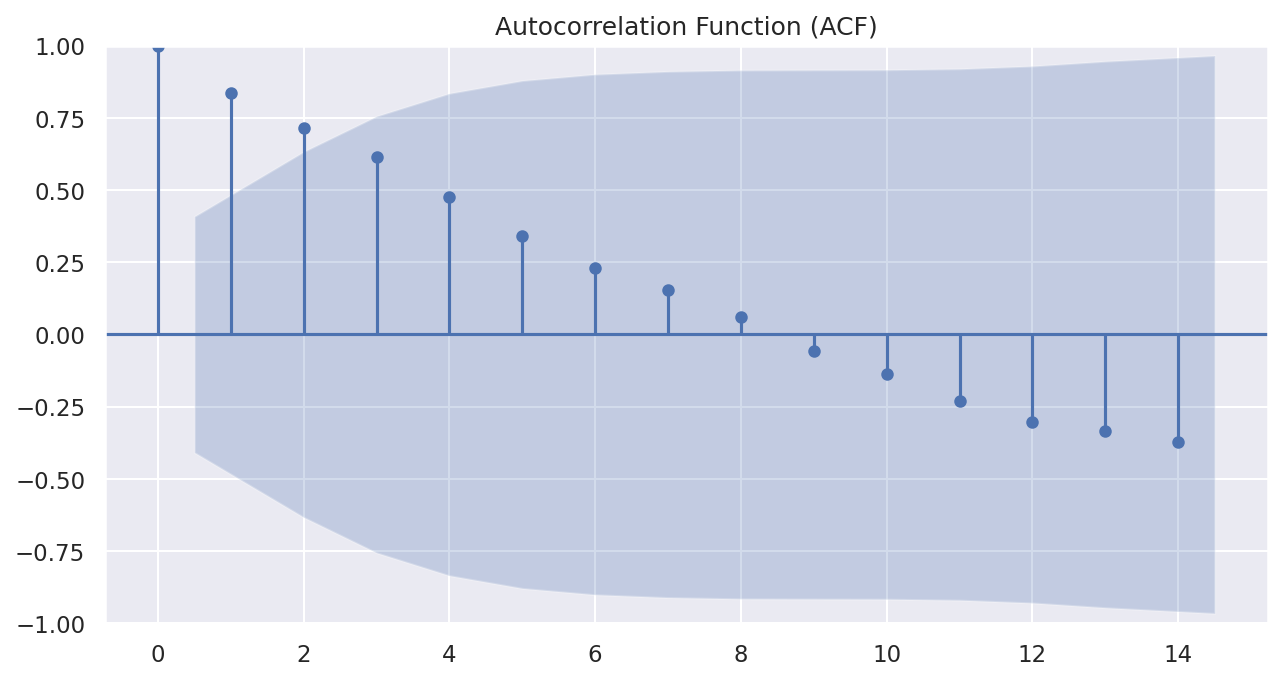

In [ ]:
# Import library seaborn dan matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Setting kedalaman kualitas grafik dalam dpi (deep per inch)
sns.set(
    rc = {
        'figure.figsize' : (10, 5),
        'figure.dpi' : 150
    }
)

plot_acf(df[['grk']], lags=14)
plt.title('Autocorrelation Function (ACF)')
plt.show()

Pola Autokorelasi
* Nilai autokorelasi pada lag 1 hingga lag 5 menunjukkan bahwa data memiliki korelasi positif yang signifikan, menandakan adanya ketergantungan jangka pendek dalam data.
* Nilai autokorelasi mulai menurun secara bertahap dan menjadi tidak signifikan (berada dalam area interval kepercayaan, yang diwakili oleh area biru) pada lag yang lebih tinggi (setelah lag 5 atau 6).

kesimpulan
* Data IPM memiliki ketergantungan jangka pendek yang kuat, cocok untuk analisis prediktif berbasis time series.
* Tidak ada pola musiman atau siklus yang kuat.

# split data

In [ ]:
# Hitung banyak data
banyak_data = df.shape[0]
print(f'Banyak data = {banyak_data}')

# Inisialisasi proporsi yang digunakan
train_proportion = 0.75
test_proportion = 1 - train_proportion

# Hitung banyak data train dan test
train_size = int(banyak_data * train_proportion)
test_size = banyak_data - train_size

# Tampilkan data
print(f'Banyak data train = {train_size}')
print(f'Banyak data test = {test_size}')

Banyak data = 23
Banyak data train = 17
Banyak data test = 6


In [ ]:
# Proses pembagian data
X_train = df.iloc[:train_size]
X_test = df.iloc[train_size:]

# Tampilkan data train
display(X_train)

,grk
tahun,
2000-01-01,0.60
2001-01-01,0.63
2002-01-01,0.64
2003-01-01,0.67
2004-01-01,0.69
2005-01-01,0.69
2006-01-01,0.73
2007-01-01,0.75
2008-01-01,0.76


In [ ]:
# Tampilkan data test
display(X_test)

,grk
tahun,
2017-01-01,1.02
2018-01-01,1.11
2019-01-01,1.16
2020-01-01,1.10
2021-01-01,1.13
2022-01-01,1.24


# Modeling

## 1. ARIMA (AutoRegressive Integrated Moving Average)

ARIMA dirumuskan :

\begin{equation}
y_t = \mu + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_p y_{t-p} + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \cdots + \theta_q \epsilon_{t-q} + \epsilon_t
\end{equation}

ARIMA(p, d, q) memiliki tiga parameter utama:

* p : Order dari model autoregressive (AR)
* d : Jumlah diferensiasi yang diperlukan untuk membuat data stasioner.
* q : Order dari model moving average (MA).

In [ ]:
# Import library plotly untuk visualisasi data
import plotly.express as px

def plot_prediksi(hasil_prediksi, x, y, mae, params = None):
    fig = px.line(
        data_frame = hasil_prediksi,
        x = x,
        y = y,
        color_discrete_sequence = ['#10375C', '#F3C623']
    )

    fig.update_layout(
        width = 1200,
        height = 500,
        showlegend = False,
        plot_bgcolor = 'rgba(0, 0, 0, 0)',
        title = dict(
            text = f"<b>Hasil Prediksi (MAE : {mae})<b><br><sup><sup><span style='color:#000435;font-size:10'>Parameter : {params}</span></sup></sup>",
            font = dict(
                size = 28,
                color = '#757882'
            ),
            y = 0.92,
            x = 0.5
        ),
        yaxis = dict(
            title = '',
            showgrid = False,
            showline = False,
            showticklabels = False,
            zeroline = False,
        ),
        margin = dict(
            t = 80,
            b = 10,
            r = 20
        )
    )

    fig.show(renderer='colab')

###  Pencarian Parameter Terbaik ARIMA

In [ ]:
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
from itertools import product

# Tentukan rentang nilai p, d, q yang akan diuji
p_values = range(0, 6)  # AR term
d_values = range(0, 6)  # Differencing term
q_values = range(0, 6)  # MA term

# Buat grid search untuk kombinasi parameter (p, d, q)
parameters = list(product(p_values, d_values, q_values))

# Fungsi untuk mengevaluasi model ARIMA
def evaluate_arima_model(train, test, p, d, q):
    try:
        # Fit model ARIMA
        model = ARIMA(train, order=(p, d, q))
        model_fit = model.fit()

        # Prediksi dengan model yang telah dilatih
        forecast = model_fit.forecast(steps = test.shape[0])

        #if(d > 0):
            # Mengembalikan hasil prediksi yang sudah di-differencing ke dalam bentuk asli
        #    forecast = X_train.iloc[-1] + forecast.cumsum()

        # Hitung error prediksi
        mae = mean_absolute_error(test, forecast)

        prediksi = test.copy()
        prediksi['predict'] = forecast.tolist()

        plot_prediksi(
            prediksi,
            x = prediksi.index,
            y = ['grk',	'predict'],
            mae = round(mae, 4),
            params = f'(p={p}, d={d}, q={q})'
        )

        return mae, forecast
    except:
        return np.nan, np.nan  # Jika terjadi error (misal model tidak konvergen), return NaN

# Grid search untuk parameter terbaik
best_mae_ARIMA = float('inf')
best_params_ARIMA = None

for param in parameters:
    p, d, q = param
    mae, forecast = evaluate_arima_model(X_train, X_test, p, d, q)
    if mae < best_mae_ARIMA:
        best_mae_ARIMA = mae
        best_params_ARIMA = param
        best_forecast_ARIMA = forecast

Output hidden; open in https://colab.research.google.com to view.

### Parameter Terbaik ARIMA

In [ ]:
# Output hasil terbaik
print(f"Best Parameters (p, d, q): {best_params_ARIMA}")
print(f"Best Mean Absolute Error: {best_mae_ARIMA}")

Best Parameters (p, d, q): (4, 1, 5)
Best Mean Absolute Error: 0.03981774282410203


### Model ARIMA dengan Best Parameter

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model
model = ARIMA(X_train, order=(best_params_ARIMA[0], best_params_ARIMA[1], best_params_ARIMA[2]))
model_fit = model.fit()

# Ringkasan model
print(model_fit.summary())

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.



                               SARIMAX Results                                
Dep. Variable:                    grk   No. Observations:                   17
Model:                 ARIMA(4, 1, 5)   Log Likelihood                  34.799
Date:                Sat, 23 Nov 2024   AIC                            -49.599
Time:                        05:25:01   BIC                            -41.873
Sample:                    01-01-2000   HQIC                           -49.203
                         - 01-01-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9987      8.274      0.121      0.904     -15.217      17.215
ar.L2         -0.8779      8.893     -0.099      0.921     -18.307      16.551
ar.L3          1.0784      4.151      0.260      0.7

/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



## 2. Double Exponential Smoothing

DES dirumuskan sebagai :      

\begin{equation}
l_t = \alpha\cdot y_{t} + (1-\alpha)(l_{t-1}+b_{t-1})\\
b_t = \beta(l_{t}-l_{t-1})+(1-\beta)b_{t-1}\\
\hat{y}_{t+k} = l_t + k \cdot b_t
\end{equation}

DES(α, β) memiliki dua parameter utama:

* α : Smoothing Level
* β : Smoothing Trend

### Pencarian Parameter Terbaik DES

In [ ]:
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error
from itertools import product

# Tentukan rentang nilai p, d, q yang akan diuji
alpha = np.arange(0, 1, 0.1)
beta = np.arange(0, 1, 0.1)

# Buat grid search untuk kombinasi parameter
parameters = list(product(alpha, beta))

# Fungsi untuk mengevaluasi model DSE
def evaluate_exponential_smoothing_model(train, test, alpha, beta):
    try:
        # Double Exponential Smoothing (Holt's Linear Trend)
        model = ExponentialSmoothing(train, trend='add', seasonal=None)
        model_fit = model.fit(smoothing_level=alpha, smoothing_trend=beta)

        # Forecast
        forecast = model_fit.forecast(steps=test.shape[0])

        # Hitung error prediksi
        mae = mean_absolute_error(test, forecast)

        prediksi = test.copy()
        prediksi['predict'] = forecast.tolist()

        plot_prediksi(
            prediksi,
            x = prediksi.index,
            y = ['grk',	'predict'],
            mae = round(mae, 4),
            params = f'(alpha={alpha:.2f}, beta={beta:.2f})'
        )

        return mae, forecast
    except:
        return np.nan, np.nan  # Jika terjadi error (misal model tidak konvergen), return NaN

# 4. Grid search untuk parameter terbaik
best_mae_DES = float('inf')
best_params_DES = None

for param in parameters:
    alpha, beta = param
    mae, forecast = evaluate_exponential_smoothing_model(X_train, X_test, alpha, beta)
    if mae < best_mae_DES:
        best_mae_DES = mae
        best_params_DES = param
        best_forecast_DES = forecast

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.



/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.



/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.



/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.



/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.



...

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.



/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.



/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.



/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.



/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.



### Parameter Terbaik DES

In [ ]:
# Output hasil terbaik
print(f"Best Parameters (alpha, beta): ({best_params_DES[0]:.2f}, {best_params_DES[1]:.2f})")
print(f"Best Mean Absolute Error: {best_mae_DES}")

Best Parameters (alpha, beta): (0.10, 0.70)
Best Mean Absolute Error: 0.03888073829934576


### Model DES dengan Best Parameter

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit ARIMA model
model = ExponentialSmoothing(X_train, trend='add', seasonal=None)
model_fit = model.fit(smoothing_level = best_params_DES[0], smoothing_trend = best_params_DES[1])

# Ringkasan model
print(model_fit.summary())

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.



                       ExponentialSmoothing Model Results                       
Dep. Variable:                      grk   No. Observations:                   17
Model:             ExponentialSmoothing   SSE                              0.018
Optimized:                         True   AIC                           -108.410
Trend:                         Additive   BIC                           -105.077
Seasonal:                          None   AICC                          -100.010
Seasonal Periods:                  None   Date:                 Sat, 23 Nov 2024
Box-Cox:                          False   Time:                         05:25:11
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.1000000                alpha                False
smoothing_trend            0.70000

## FB Prophet

In [ ]:
X_train = X_train.reset_index()

# Untuk fbprophet kolom tanggal diberi nama ds dan kolom nilai diberi nama y
X_train = X_train.rename(columns = {
    'tahun' : 'ds',
    'grk' : 'y'
})

### Pencarian Parameter Terbaik FB Prophet

In [ ]:
from prophet import Prophet
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_absolute_error
from datetime import timedelta

# Menentukan parameter grid untuk tuning
param_grid = {
    'daily_seasonality': [False, True],
    'weekly_seasonality': [False, True],
    'yearly_seasonality': [False, True],
    'changepoint_prior_scale': [0.01, 0.1, 0.5],
    'seasonality_prior_scale': [1, 10, 20],
    'seasonality_mode' : ['additive', 'multiplicative'],
}

# Menyimpan hasil
results = list()

# Melakukan grid search
for params in ParameterGrid(param_grid):
    model = Prophet(**params)
    model.fit(X_train)

    # Membuat prediksi
    future = model.make_future_dataframe(periods = X_test.shape[0], freq='Y')
    forecast = model.predict(future)

    # Menghitung MAE untuk data test
    mae = mean_absolute_error(X_test['grk'], forecast.iloc[train_size:]['yhat'])
    results.append({'params': params, 'mae': mae})

    forecast_test = forecast.iloc[train_size:][['ds', 'yhat']]
    forecast_test['ds'] = forecast_test['ds'].apply(lambda x : x + timedelta(days=1) if x.day == 31 else x)

    hasil_prediksi = X_test.reset_index().merge(forecast_test, left_on = 'tahun', right_on = 'ds', how = 'left').drop('ds', axis = 1)

    plot_prediksi(
        hasil_prediksi,
        x = 'tahun',
        y = ['grk', 'yhat'],
        mae = round(mae, 4),
        params = params
    )

    if(len(results) == 1):
        best_mae = mae
        best_params = params
        best_forecast = forecast
    else:
        if(mae < best_mae):
            best_mae = mae
            best_params = params
            best_forecast = forecast

INFO:prophet:n_changepoints greater than number of observations. Using 12.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnflxqnnt/57ap0j3z.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnflxqnnt/_fiqy7h3.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=8424', 'data', 'file=/tmp/tmpnflxqnnt/57ap0j3z.json', 'init=/tmp/tmpnflxqnnt/_fiqy7h3.json', 'output', 'file=/tmp/tmpnflxqnnt/prophet_modelwrl994zc/prophet_model-20241123052511.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:25:11 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
05:25:11 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


INFO:prophet:n_changepoints greater than number of observations. Using 12.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnflxqnnt/17drcpvc.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnflxqnnt/1uqpcz37.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=70234', 'data', 'file=/tmp/tmpnflxqnnt/17drcpvc.json', 'init=/tmp/tmpnflxqnnt/1uqpcz37.json', 'output', 'file=/tmp/tmpnflxqnnt/prophet_model_8cvj6ji/prophet_model-20241123052512.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:25:12 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
05:25:12 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


INFO:prophet:n_changepoints greater than number of observations. Using 12.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnflxqnnt/rlshoxt4.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnflxqnnt/nmbv_h94.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=53229', 'data', 'file=/tmp/tmpnflxqnnt/rlshoxt4.json', 'init=/tmp/tmpnflxqnnt/nmbv_h94.json', 'output', 'file=/tmp/tmpnflxqnnt/prophet_modelm53t6pxr/prophet_model-20241123052512.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:25:12 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
05:25:12 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


INFO:prophet:n_changepoints greater than number of observations. Using 12.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnflxqnnt/ebcjo1g8.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnflxqnnt/1wn1le60.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=2201', 'data', 'file=/tmp/tmpnflxqnnt/ebcjo1g8.json', 'init=/tmp/tmpnflxqnnt/1wn1le60.json', 'output', 'file=/tmp/tmpnflxqnnt/prophet_modelsk_kz3zh/prophet_model-20241123052512.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:25:12 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
05:25:12 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


INFO:prophet:n_changepoints greater than number of observations. Using 12.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnflxqnnt/fzkjrcdb.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnflxqnnt/mxo5id3h.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=50645', 'data', 'file=/tmp/tmpnflxqnnt/fzkjrcdb.json', 'init=/tmp/tmpnflxqnnt/mxo5id3h.json', 'output', 'file=/tmp/tmpnflxqnnt/prophet_model0vsafhhu/prophet_model-20241123052512.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:25:12 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
05:25:13 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


...

INFO:prophet:n_changepoints greater than number of observations. Using 12.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnflxqnnt/7sd4f6sr.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnflxqnnt/_ee_bhu_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=65234', 'data', 'file=/tmp/tmpnflxqnnt/7sd4f6sr.json', 'init=/tmp/tmpnflxqnnt/_ee_bhu_.json', 'output', 'file=/tmp/tmpnflxqnnt/prophet_modelo_9txm9m/prophet_model-20241123053050.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:30:50 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
05:31:06 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


INFO:prophet:n_changepoints greater than number of observations. Using 12.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnflxqnnt/bav_k1i1.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnflxqnnt/y0ev300s.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=33896', 'data', 'file=/tmp/tmpnflxqnnt/bav_k1i1.json', 'init=/tmp/tmpnflxqnnt/y0ev300s.json', 'output', 'file=/tmp/tmpnflxqnnt/prophet_modelu82fts57/prophet_model-20241123053107.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:31:07 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
05:31:07 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


INFO:prophet:n_changepoints greater than number of observations. Using 12.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnflxqnnt/f9o1ixjl.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnflxqnnt/p3g0vy4r.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=66492', 'data', 'file=/tmp/tmpnflxqnnt/f9o1ixjl.json', 'init=/tmp/tmpnflxqnnt/p3g0vy4r.json', 'output', 'file=/tmp/tmpnflxqnnt/prophet_modelw1i3iima/prophet_model-20241123053107.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:31:07 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
05:31:07 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


INFO:prophet:n_changepoints greater than number of observations. Using 12.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnflxqnnt/86qtm92a.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnflxqnnt/c2y1v8na.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=2460', 'data', 'file=/tmp/tmpnflxqnnt/86qtm92a.json', 'init=/tmp/tmpnflxqnnt/c2y1v8na.json', 'output', 'file=/tmp/tmpnflxqnnt/prophet_model3usbkqik/prophet_model-20241123053108.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:31:08 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
05:31:17 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


INFO:prophet:n_changepoints greater than number of observations. Using 12.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnflxqnnt/y7zitsp_.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnflxqnnt/_ul7zwfl.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=91104', 'data', 'file=/tmp/tmpnflxqnnt/y7zitsp_.json', 'init=/tmp/tmpnflxqnnt/_ul7zwfl.json', 'output', 'file=/tmp/tmpnflxqnnt/prophet_modelfdl1x3b1/prophet_model-20241123053117.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:31:17 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
05:31:34 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


### Parameter Terbaik FB Prophet

In [ ]:
print(best_params)

{'changepoint_prior_scale': 0.01, 'daily_seasonality': True, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 1, 'weekly_seasonality': True, 'yearly_seasonality': True}


In [ ]:
# Output hasil terbaik
print(f"Best Parameters FB Prophet: {best_params}")
print(f"Best Mean Absolute Error: {best_mae}")

Best Parameters FB Prophet: {'changepoint_prior_scale': 0.01, 'daily_seasonality': True, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 1, 'weekly_seasonality': True, 'yearly_seasonality': True}
Best Mean Absolute Error: 0.037801618457615316


### Model FB Prophet dengan Best Parameter

In [ ]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error
from datetime import timedelta

model = Prophet(
    changepoint_prior_scale = 0.01,
    daily_seasonality = True,
    seasonality_mode = 'additive',
    seasonality_prior_scale = 1,
    weekly_seasonality = True,
    yearly_seasonality = True
)

model.fit(X_train)

# Membuat prediksi
future = model.make_future_dataframe(periods = X_test.shape[0], freq='Y')
forecast = model.predict(future)

forecast['ds'] = forecast['ds'].apply(lambda x : x + timedelta(days=1) if x.day == 31 else x)

# Menghitung MAE untuk data test
mae = mean_absolute_error(X_test['grk'], forecast.iloc[train_size:]['yhat'])

forecast_test = forecast.iloc[train_size:][['ds', 'yhat']]

INFO:prophet:n_changepoints greater than number of observations. Using 12.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnflxqnnt/emh2rnyp.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnflxqnnt/phlezdsm.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=31821', 'data', 'file=/tmp/tmpnflxqnnt/emh2rnyp.json', 'init=/tmp/tmpnflxqnnt/phlezdsm.json', 'output', 'file=/tmp/tmpnflxqnnt/prophet_model4rtjupwg/prophet_model-20241123053236.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:32:36 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
05:32:36 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
print(mae)

0.037801618457615316


# FInal Model

<h1> dari ketiga model yang sudah dibuat didapat hasil model terbaik yaitu model DES

## Model DES

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit ARIMA model
model = ExponentialSmoothing(df, trend='add', seasonal=None)
model_fit = model.fit(smoothing_level = 0.10, smoothing_trend = 0.70)

# Ringkasan model
print(model_fit.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                      grk   No. Observations:                   23
Model:             ExponentialSmoothing   SSE                              0.030
Optimized:                         True   AIC                           -144.721
Trend:                         Additive   BIC                           -140.179
Seasonal:                          None   AICC                          -139.471
Seasonal Periods:                  None   Date:                 Sat, 23 Nov 2024
Box-Cox:                          False   Time:                         05:44:13
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.1000000                alpha                False
smoothing_trend            0.70000

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.



In [ ]:
df['type'] = 'Actual'

In [ ]:
# Prediksi hingga 6 tahun kedepan
forecast = model_fit.forecast(steps = 8).to_frame()

forecast = forecast.rename(columns = {0 : 'grk'})
forecast = pd.concat([df.iloc[-1:], forecast])

forecast['type'] = 'Forecast'

In [ ]:
forecast.head()

,grk,type
2022-01-01,1.240000,Forecast
2023-01-01,1.227983,Forecast
2024-01-01,1.260776,Forecast
2025-01-01,1.293570,Forecast
2026-01-01,1.326363,Forecast


In [ ]:
full_forecast = pd.concat([df, forecast])

In [ ]:
full_forecast

,grk,type
2000-01-01,0.600000,Actual
2001-01-01,0.630000,Actual
2002-01-01,0.640000,Actual
2003-01-01,0.670000,Actual
2004-01-01,0.690000,Actual
2005-01-01,0.690000,Actual
2006-01-01,0.730000,Actual
2007-01-01,0.750000,Actual
2008-01-01,0.760000,Actual
2009-01-01,0.790000,Actual


In [ ]:
# Import library plotly untuk visualisasi data
import plotly.express as px

fig = px.line(
    data_frame = full_forecast,
    x = full_forecast.index,
    y = 'grk',
    color = 'type',
    color_discrete_sequence = ['#78B3CE', '#F3C623']
)

fig.add_trace(
    px.scatter(
        data_frame = full_forecast.iloc[:1],
        x = full_forecast.iloc[:1].index,
        y = 'grk',
        size = [3],
        # Pewarnaan pada scatter chart
        color_discrete_sequence = ['#000435'],
    ).data[0]
)


fig.add_annotation(
    x = full_forecast.iloc[:1].index.date[0],
    y = full_forecast.iloc[:1]['grk'].values[0],
    text = f"Tahun 2000",
    yanchor = 'bottom',
    showarrow = False,
    font = dict(
        size = 12,
        color = "#544018",
        family = "sans serif"
    ),
    align = "left",
    yshift = 20,
    opacity = 0.8
)

fig.add_trace(
    px.scatter(
        data_frame = full_forecast.iloc[-1:],
        x = full_forecast.iloc[-1:].index,
        y = 'grk',
        size = [3],
        # Pewarnaan pada scatter chart
        color_discrete_sequence = ['#F3C623'],
    ).data[0]
)

# Annotation untuk tahun 2030
fig.add_annotation(
    x = full_forecast.iloc[-1:].index.date[0],
    y = full_forecast.iloc[-1:]['grk'].values[0],
    text = f"Di Tahun 2030, GRK di Indonesia diprediksi akan terus meningkat<br>",
    yanchor = 'bottom',
    showarrow = False,
    font = dict(
        size = 12,
        color = "#544018",
        family = "sans serif"
    ),
    align = "left",
    yshift = 20,
    opacity = 0.8
)

fig.update_layout(
    width = 1200,
    height = 500,
    showlegend = False,
    plot_bgcolor = 'rgba(0, 0, 0, 0)',
    title = dict(
        text = f"<b>Apakah di Tahun 2030,<br><span style='color:#000B58;'>tren Emisi Gas Rumah kaca (GRK) di indonesia terus meningkat </span>?",
        font = dict(
            size = 17,
            color = '#757882'
        ),
        y = 0.92,
        x = 0.5
    ),
    yaxis = dict(
        title = '',
        showgrid = False,
        showline = False,
        showticklabels = False,
        zeroline = False,
    ),
    margin = dict(
        t = 80,
        b = 10,
        r = 20
    )
)

fig.show(renderer = 'colab')

In [ ]:
full_forecast.to_csv('MODEL DATA GRK.csv', index=True) # index=True to keep the date index